In [1]:
import numpy as np
import pandas as pd
import copy
from scipy.optimize import nnls, minimize

df = pd.read_csv("data.csv", index_col=0)
df

c:\Users\natal\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


,PSC,JUNTS,ERC,PP,VOX,COMUNS,CUP,ALIANÇA.CAT,Altres,Cs,Abstenció
1980,0.138185,0.171275,0.054873,0.014556,0.000000,0.115557,0.000000,0.000000,0.117144,0.000000,0.388410
1984,0.193811,0.301318,0.028411,0.049647,0.000000,0.035962,0.000000,0.000000,0.031802,0.000000,0.359048
1988,0.177197,0.272179,0.024616,0.031648,0.000000,0.046166,0.000000,0.000000,0.039541,0.000000,0.408652
1992,0.152089,0.255296,0.043962,0.032968,0.000000,0.035913,0.000000,0.000000,0.025621,0.000000,0.454152
1995,0.159822,0.263467,0.061096,0.084246,0.000000,0.062607,0.000000,0.000000,0.005756,0.000000,0.363006
1999,0.227821,0.226843,0.052261,0.057211,0.000000,0.015129,0.000000,0.000000,0.016845,0.000000,0.403890
2003,0.198586,0.196993,0.104874,0.075627,0.000000,0.046480,0.000000,0.000000,0.008517,0.000000,0.368922
2006,0.153722,0.180767,0.080571,0.060980,0.000000,0.054760,0.000000,0.000000,0.013357,0.017425,0.438418
2010,0.111491,0.234199,0.042640,0.075148,0.000000,0.044927,0.000000,0.000000,0.061473,0.020696,0.409426
2012,0.101217,0.215104,0.095984,0.091014,0.000000,0.069380,0.024398,0.000000,0.040548,0.053099,0.309256


In [2]:
list(df.columns)

['PSC',
 'JUNTS',
 'ERC',
 'PP',
 'VOX',
 'COMUNS',
 'CUP',
 'ALIANÇA.CAT',
 'Altres',
 'Cs',
 'Abstenció']

Simulant l'extinció de 'Cs' per a futures prediccions...
Model ajustat correctament amb pesos temporals (Decay Rate: 0.01)
Model de Cadena de Markov Estable (14 Anys, 11 Partits)
Matriu de Transició Global (Files = Destí, Columnes = Origen):
                PSC   JUNTS     ERC      PP     VOX  COMUNS     CUP  ALIANÇA.CAT  Altres      Cs  Abstenció
PSC          0.7808  0.0054  0.0033  0.0028  0.0095  0.0759  0.0080          0.0  0.0440  0.0007     0.0712
JUNTS        0.0027  0.6016  0.0000  0.0000  0.0000  0.0737  0.0000          0.0  0.1627  0.0000     0.2033
ERC          0.0000  0.1144  0.6199  0.0416  0.0000  0.0000  0.0018          0.0  0.0043  0.0018     0.0053
PP           0.0003  0.0000  0.0000  0.9203  0.0065  0.0000  0.0000          0.0  0.0025  0.0000     0.0415
VOX          0.0000  0.0000  0.0013  0.0004  0.9839  0.0028  0.0002          0.0  0.0000  0.0033     0.0123
COMUNS       0.0033  0.0021  0.0000  0.0033  0.0000  0.7581  0.0000          0.0  0.0000  0.0000     0.0135
CU

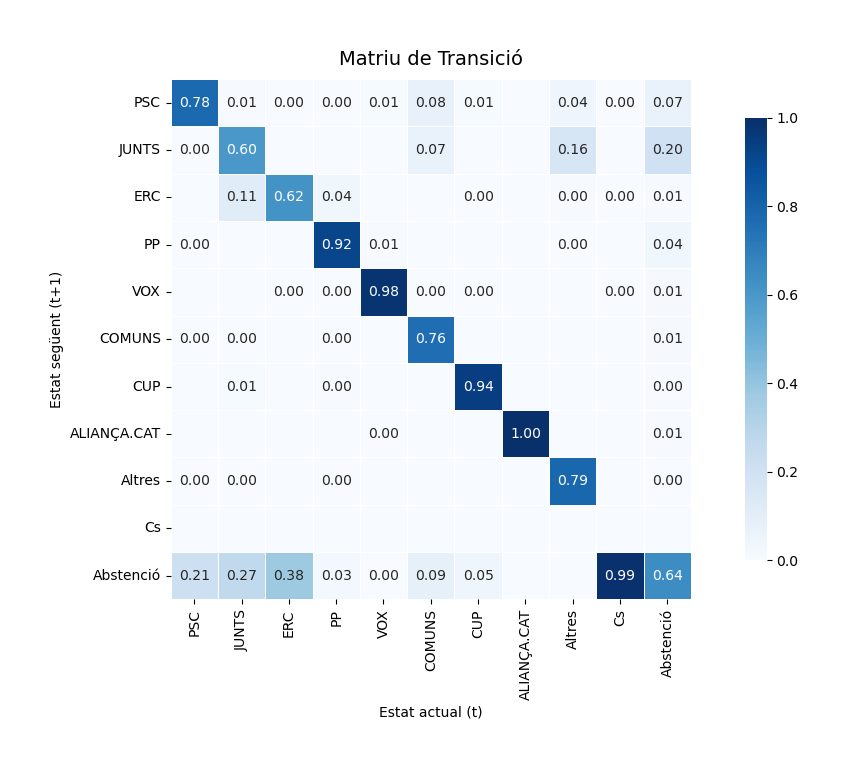

In [3]:
from utils import StableMarkovChain

mc = StableMarkovChain(df)
mc.fit(decay_rate=0.01,sparse_threshold=1e-9,fidelitat_threshold=0)

print(mc)
mc.plot_transition_matrix()

La matriu és reductible. Calculant comportament a llarg termini amb P^1000...
PSC            0.026346
JUNTS          0.032870
ERC            0.014982
PP             0.037518
VOX            0.055135
COMUNS         0.004616
CUP            0.014143
ALIANÇA.CAT    0.752154
Altres         0.000269
Cs             0.000000
Abstenció      0.061968
dtype: float64


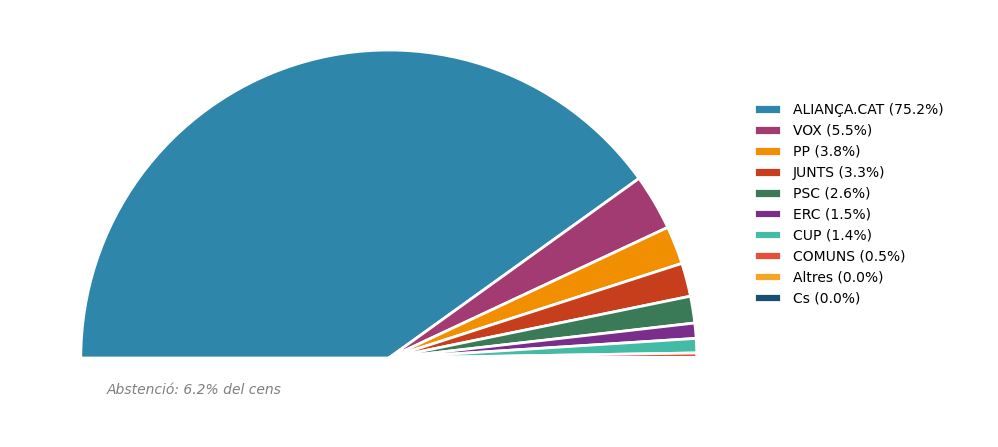

In [4]:
print(mc.get_steady_state())
mc.plot_steady_state('steady_state_basic.png')

In [5]:
"""import numpy as np

eigenvalues, eigenvectors = np.linalg.eig(df_P_final)

# Trobar l'índex de l'autovalor més proper a 1
idx = np.argmin(np.abs(eigenvalues - 1))

# Extreure el vector i normalitzar (suma = 1)
pi = np.real(eigenvectors[:, idx])
pi = pi / pi.sum()

partits = list(df_P_final.columns)
for p, v in zip(partits, pi):
    print(f"{p:10s}: {v:.4f}")

###### COMPROVACIÓ DE LA DISTRIBUCIÓ ESTACIONÀRIA ######
print("\nComprovació de la distribució estacionària:")
print(np.allclose(df_P_final @ pi, pi))  # Ha de donar True
print(pi.sum())                    # Ha de donar 1.0"""

'import numpy as np\n\neigenvalues, eigenvectors = np.linalg.eig(df_P_final)\n\n# Trobar l\'índex de l\'autovalor més proper a 1\nidx = np.argmin(np.abs(eigenvalues - 1))\n\n# Extreure el vector i normalitzar (suma = 1)\npi = np.real(eigenvectors[:, idx])\npi = pi / pi.sum()\n\npartits = list(df_P_final.columns)\nfor p, v in zip(partits, pi):\n    print(f"{p:10s}: {v:.4f}")\n\n###### COMPROVACIÓ DE LA DISTRIBUCIÓ ESTACIONÀRIA ######\nprint("\nComprovació de la distribució estacionària:")\nprint(np.allclose(df_P_final @ pi, pi))  # Ha de donar True\nprint(pi.sum())                    # Ha de donar 1.0'

Per al Teorema de Perron-Frobenius, una cadena de Markov irreductible i aperiòdica sempre té una única distribució estacionària π > 0.

In [6]:
mc.verify_steady_state()

VERIFICACIÓ DE L'EXISTÈNCIA DE LA DISTR. ESTACIONÀRIA

1. Matriu estocàstica (columnes sumen 1):
   · Sumes de cada columna: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
   · Columnes sumen 1:      True
   · Valors no negatius:    True

2. Irreductibilitat (tots els estats es comuniquen): False

No és irreductible. ÉS REDUCTIBLE → No es pot garantir una distribució estacionària única.


False

In [7]:
mc.export_for_flourish("election_flows_basic.csv")

[OK] Flourish file saved: election_flows_basic.csv


,target,source,value
0,PSC,PSC,0.121063
1,PSC,JUNTS,0.000643
2,PSC,ERC,0.000250
3,PSC,PP,0.000168
4,PSC,VOX,0.000417
5,PSC,COMUNS,0.002458
6,PSC,CUP,0.000182
8,PSC,Altres,0.000731
10,PSC,Abstenció,0.032174
11,JUNTS,PSC,0.000424


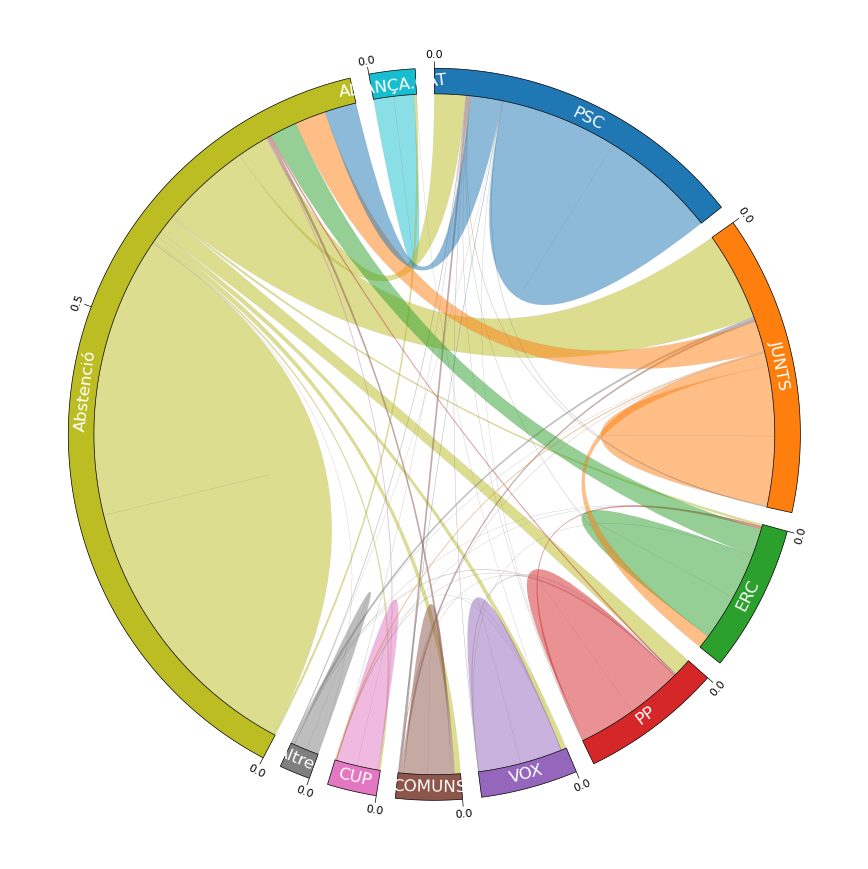

In [8]:
mc.plot_chord()

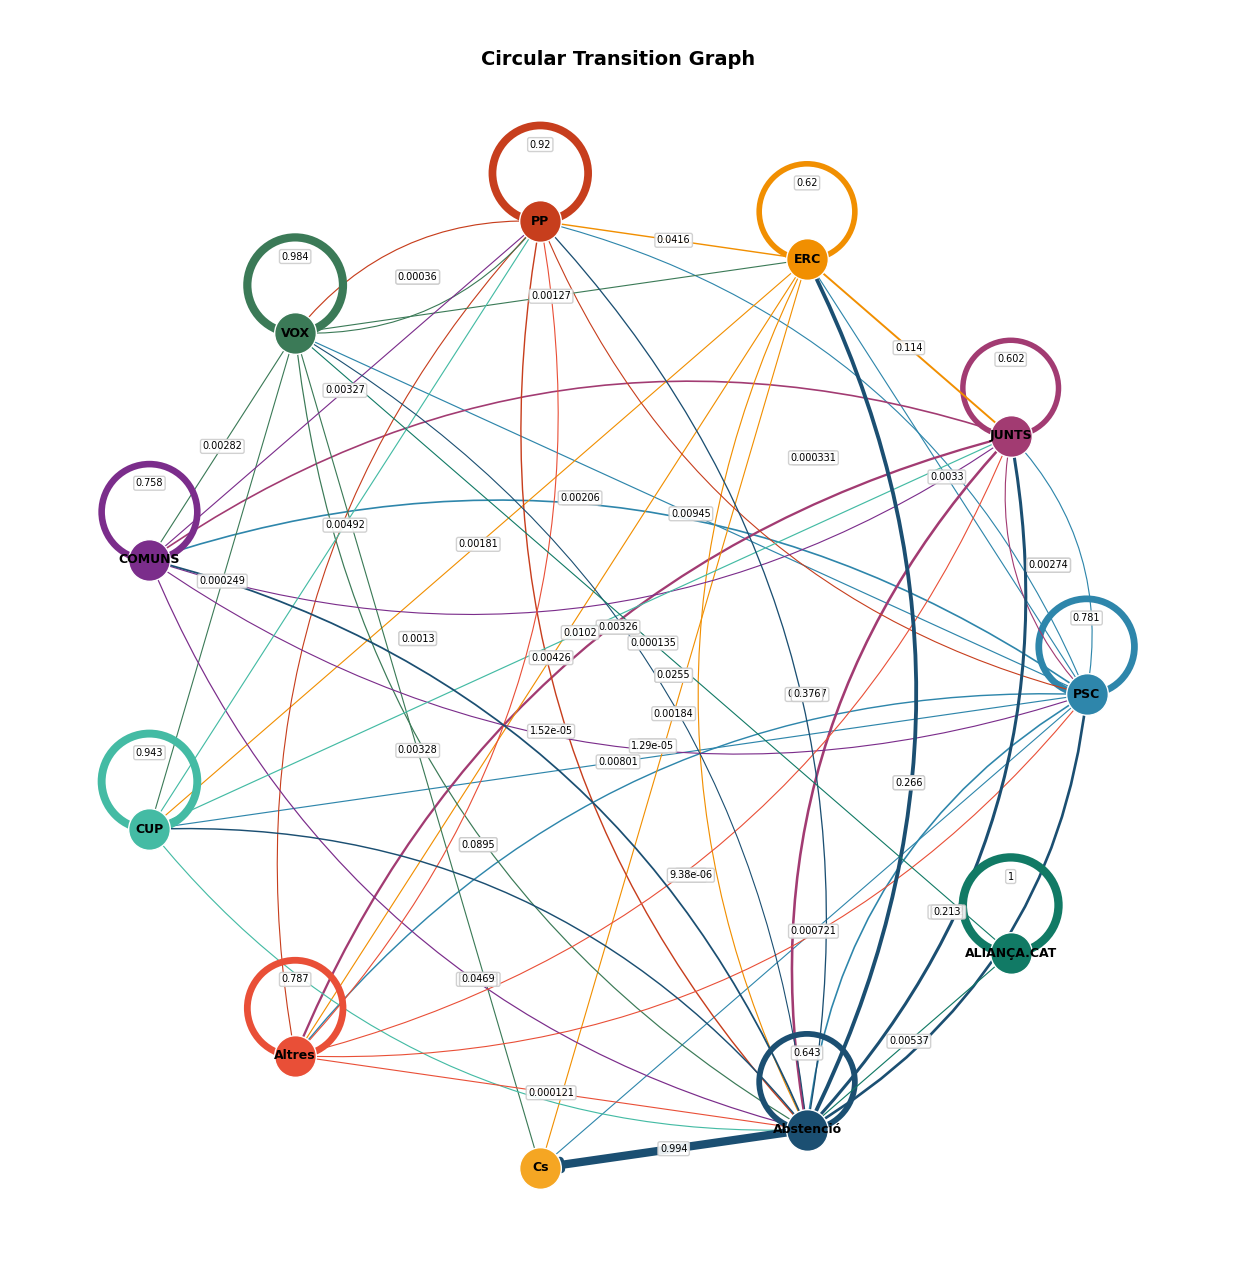

In [9]:
mc.plot_graph()

### Efecte d'una campanya
Per fer-ho canviem un valor de la matriu de transició, augmentant el nombre de votants que es queden del partit politic que fa la campanya.

In [10]:
col = "ERC"
mc2 = copy.deepcopy(mc)
mc2.transition_matrix.loc[col, col] = 0.9

# Renormalitzem la fila
mc2.transition_matrix[col] /= mc2.transition_matrix[col].sum()

# Verifiquem que segueix sumant 1
print(mc2.transition_matrix[col].sum())

1.0000000000000002


La matriu és reductible. Calculant comportament a llarg termini amb P^1000...
PSC            0.026513
JUNTS          0.033085
ERC            0.019320
PP             0.037747
VOX            0.055415
COMUNS         0.004645
CUP            0.014228
ALIANÇA.CAT    0.746399
Altres         0.000271
Cs             0.000000
Abstenció      0.062377
dtype: float64


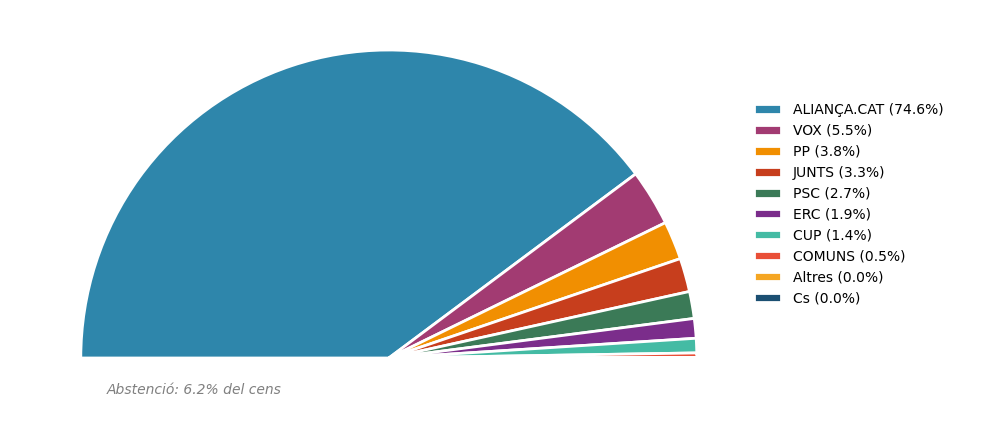

In [11]:
print(mc2.get_steady_state())
mc2.plot_steady_state()

### Temps per arribar a solució estacionària

Fem una simulació de l'evolució de la matriu de transició a partir de l'estat incial (any 1980). Amb aquesta simulació veiem en quantes eleccions arriba a la solució estàcionaria que haviem calculat anteriorment i fem una aproximació per calcular els anys total (num_eleccions * 4)

In [12]:
pi = mc.get_steady_state().values
p0 = df.loc[1980].values
epsilon = 1e-5
p = p0.copy()
t = 0
historia = [p.copy()]

P = mc.transition_matrix.values

# Afegeix un màxim de passos per seguretat
MAX_PASSOS = 10000

while t < MAX_PASSOS:
    p_nou = P @ p
    diferencia = np.max(np.abs(p_nou - pi))
    historia.append(p_nou.copy())
    t += 1
    if diferencia < epsilon:
        break
    p = p_nou

if t == MAX_PASSOS:
    print("No ha convergit en el màxim de passos!")

print(f"Convergència assolida en {t} eleccions (~{t*4} anys)")
print(f"Distribució estacionària π:")
for partit, prob in zip(list(df.columns), pi):
    print(f"  {partit}: {prob:.3f}")

La matriu és reductible. Calculant comportament a llarg termini amb P^1000...
No ha convergit en el màxim de passos!
Convergència assolida en 10000 eleccions (~40000 anys)
Distribució estacionària π:
  PSC: 0.026
  JUNTS: 0.033
  ERC: 0.015
  PP: 0.038
  VOX: 0.055
  COMUNS: 0.005
  CUP: 0.014
  ALIANÇA.CAT: 0.752
  Altres: 0.000
  Cs: 0.000
  Abstenció: 0.062


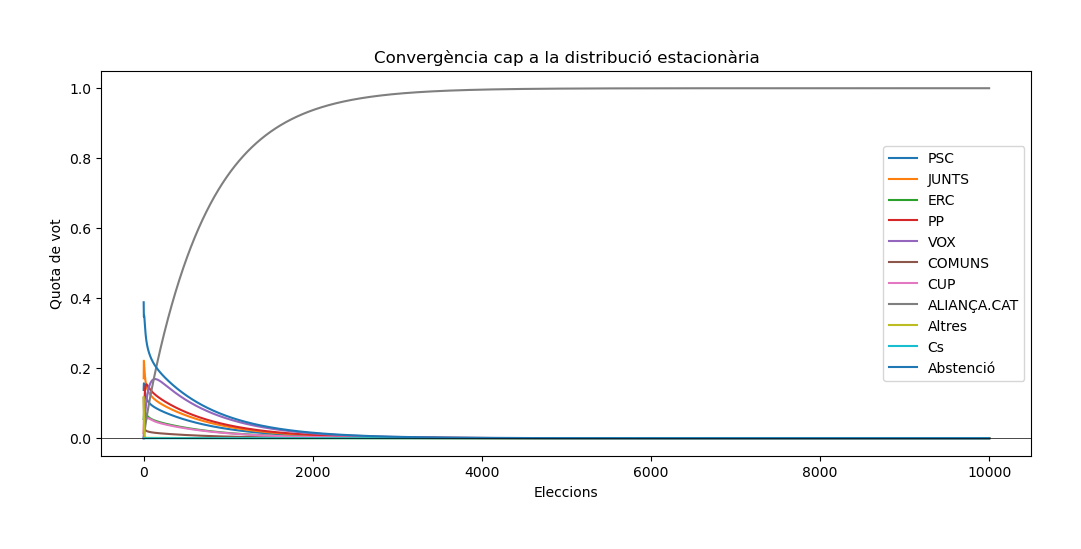

In [13]:
import matplotlib.pyplot as plt

historia = np.array(historia)

plt.figure(figsize=(12, 5))
for j, partit in enumerate(list(df.columns)):
    plt.plot(historia[:, j], label=partit)
plt.axhline(y=0, color='k', linewidth=0.5)
plt.xlabel("Eleccions")
plt.ylabel("Quota de vot")
plt.title("Convergència cap a la distribució estacionària")
plt.legend()
plt.show()

### Costumer lifetime value

Busquem el número d'eleccions consecutives que de mitjana un votant votaria al mateix partit: $\frac{1}{1-retenció}$

In [14]:
retencio = mc.transition_matrix.values.diagonal()
print("Retenció (probabilitat de mantenir votants):")

clv = 1 / (1 - retencio)

print("CLV (Customer Lifetime Value) estimat per cada partit:")
for partit, clv_value in zip(list(df.columns), clv):
    print(f"  {partit}: {round(clv_value, 2)} ~ {round(clv_value, 0)} eleccions")

Retenció (probabilitat de mantenir votants):
CLV (Customer Lifetime Value) estimat per cada partit:
  PSC: 4.56 ~ 5.0 eleccions
  JUNTS: 2.51 ~ 3.0 eleccions
  ERC: 2.63 ~ 3.0 eleccions
  PP: 12.54 ~ 13.0 eleccions
  VOX: 62.07 ~ 62.0 eleccions
  COMUNS: 4.13 ~ 4.0 eleccions
  CUP: 17.55 ~ 18.0 eleccions
  ALIANÇA.CAT: inf ~ inf eleccions
  Altres: 4.68 ~ 5.0 eleccions
  Cs: 1.0 ~ 1.0 eleccions
  Abstenció: 2.8 ~ 3.0 eleccions


C:\Users\natal\AppData\Local\Temp\ipykernel_55464\2549160280.py:4: RuntimeWarning: divide by zero encountered in divide
  clv = 1 / (1 - retencio)
